### Sketch some stuff

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mudata as md
import warnings

from src import FeatureMapping, HierarchicalMuData, make_synthetic_proteomics_data

### Focus on getting the indices back from the adjacency matrix in varp

1. Generate an adjacency matrix and populate it with values

## Validation

In [2]:
# Check that the level is in the matrix bounds
def _validate_query_level(query_level: str, matrix_bounds: dict[str, tuple[int, int]]):
    if query_level not in matrix_bounds.keys():
        raise ValueError(f"Query level {query_level} not found in matrix bounds.")

# Check that the feature boundaries are consistent with the adjacency matrix size
def _validate_feature_bounds(feature_boundaries: dict[str, tuple[int, int]], adjacency_matrix: np.ndarray):
    total_range = sum(end - start for start, end in feature_boundaries.values())
    if total_range != adjacency_matrix.shape[0]:
        raise ValueError(f"Total range of feature boundaries ({total_range}) does not match adjacency matrix size ({adjacency_matrix.shape[0]}).")

# Check that the query feature is unique in the features lookup
def _check_unique_feature(features: np.ndarray, query: str):
    query_indices = np.where(features == query)[0]
    if len(query_indices) == 0:
        raise ValueError(f"Query '{query}' not found in features.")
    elif len(query_indices) > 1:
        raise ValueError(f"Query '{query}' found multiple times in features at indices {query_indices}.")

## Bound extraction

In [3]:
def _extract_feature_bounds_from_mudata(
    mdata: md.MuData,
) -> dict[str, tuple[int, int]]:
    bounds = {}
    current_index = 0
    for key, mod in mdata.mod.items():
        n_vars = mod.n_vars
        bounds[key] = (current_index, current_index + n_vars)
        current_index += n_vars
    return bounds

## Index translation

In [4]:
def feature_index_to_adjacency_index(
    query_feature_index: int,
    feature_level: str,
    feature_bounds: dict[str, tuple[int, int]],
) -> int:
    """Return actual index of query in adjacency matrix."""
    # Find the start of the requested feature level
    if feature_level not in feature_bounds:
        raise ValueError(f"Feature level '{feature_level}' not found in feature bounds")
    
    start, end = feature_bounds[feature_level]
    
    level_size = end - start
    if query_feature_index < 0 or query_feature_index >= level_size:
        raise ValueError(f"Query index {query_feature_index} out of range for level '{feature_level}' (size: {level_size})")
    
    return start + query_feature_index

def adjacency_index_to_feature_index(
    adjacency_index: int,
    feature_bounds: dict[str, tuple[int, int]],
) -> tuple[str, int]:
    """Return feature level and index of query in adjacency matrix."""
    for level, (start, end) in feature_bounds.items():
        if start <= adjacency_index < end:
            return level, adjacency_index - start
    raise ValueError(f"Adjacency index {adjacency_index} out of bounds for feature bounds.")

## Slicing operation

Assumes getting a unique numerical feature index for the current modality. Workflow would be

Loading precursor / protein / gene AnnData objects --> each of them has numerical feature indices --> creating an adjacency matrix from the concatenated indices + feature bounds

In [5]:
def slice_associated_features(
    query_feature_index: int,
    feature_level: str,
    feature_bounds: dict[str, tuple[int, int]],
    adjacency_matrix: np.ndarray,
) -> dict[str, list[int]]:
    """Convert a query feature index into a map of associated features across all levels.
    
    Works with both dense numpy arrays and sparse scipy matrices.
    
    Returns:
        Dictionary mapping feature level names to lists of feature indices that are
        connected to the query feature in the adjacency matrix.
    """
    from scipy import sparse
    
    # Convert query feature index to adjacency matrix index
    query_adjacency_index = feature_index_to_adjacency_index(
        query_feature_index=query_feature_index,
        feature_level=feature_level,
        feature_bounds=feature_bounds,
    )

    # Slice adjacency matrix to get associated features (where value is 1)
    # Handle both dense and sparse matrices
    if sparse.issparse(adjacency_matrix):
        # For sparse matrices, use getrow() to maintain 2D shape
        row = adjacency_matrix.getrow(query_adjacency_index)
        # Convert to dense 1D array for np.where
        row_dense = row.toarray().flatten()
        associated_adjacency_indices = np.where(row_dense == 1)[0]
    else:
        # For dense matrices, slice normally
        associated_adjacency_indices = np.where(adjacency_matrix[query_adjacency_index, :] == 1)[0]
    
    # Convert adjacency indices back to feature indices grouped by level
    associated_features = {level: [] for level in feature_bounds.keys()}
    
    for adj_idx in associated_adjacency_indices:
        level, feature_idx = adjacency_index_to_feature_index(
            adjacency_index=adj_idx,
            feature_bounds=feature_bounds,
        )
        associated_features[level].append(feature_idx)
    
    return associated_features

## Test with dummy adjacency matrix 

Not derived from mudata yet.

In [6]:
sides = ["GENE1", "GENE2", "PROTEIN1-1", "PROTEIN1-2", "PROTEIN2", "PRECURSOR1", "PRECURSOR2", "PRECURSOR3", "PRECURSOR4"]
am_df = pd.DataFrame({side: [0]*len(sides) for side in sides}, index=sides)

# gene1 maps to protein1-1 and protein1-2
am_df.loc["GENE1", "PROTEIN1-1"] = 1
am_df.loc["GENE1", "PROTEIN1-2"] = 1

# gene1 maps to precursor1, precursor2 and precursor3
am_df.loc["GENE1", "PRECURSOR1"] = 1
am_df.loc["GENE1", "PRECURSOR2"] = 1
am_df.loc["GENE1", "PRECURSOR3"] = 1

# protein1-1 maps to precursor1 and precursor2
am_df.loc["PROTEIN1-1", "PRECURSOR1"] = 1
am_df.loc["PROTEIN1-1", "PRECURSOR2"] = 1

# protein1-2 maps to precursor3
am_df.loc["PROTEIN1-2", "PRECURSOR3"] = 1

# gene2 maps to protein2
am_df.loc["GENE2", "PROTEIN2"] = 1

# protein2 maps to precursor4
am_df.loc["PROTEIN2", "PRECURSOR4"] = 1

# mirror that whole thing to make the matrix symmetric
am_df = am_df + am_df.T 

# every side maps to itself
for side in sides:
    am_df.loc[side, side] = 1

# Define the feature boundaries (we would get this from the constructor)
# In the real case we would generate the bounds from mudata directly
matrix_bounds = {"GENE": (0, 2), "PROTEIN": (2, 5), "PRECURSOR": (5, 9)}

In [7]:
# Test: get features associated with GENE1
slice_associated_features(
    query_feature_index=0,
    feature_level="GENE",
    feature_bounds=matrix_bounds,
    adjacency_matrix=am_df.values
)

{'GENE': [np.int64(0)],
 'PROTEIN': [np.int64(0), np.int64(1)],
 'PRECURSOR': [np.int64(0), np.int64(1), np.int64(2)]}

## Test with example MuData from GH

From https://github.com/orgs/scverse/projects/71/views/1?pane=issue&itemId=170549166&issue=scverse%7C202603_hackathon_proteomics%7C7

In [13]:
# Get test data
test_data_path = "/Users/vincenthbrennsteiner/Documents/mann_labs/_git_repositories/202603_hackathon_proteomics/msmudata/data/minimal1.h5mu"
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mdata = md.read(test_data_path)

# Extract feature bounds
feature_bounds = _extract_feature_bounds_from_mudata(mdata)

# pick a feature level to test with
feature_level = "genes"

# pick one feature to test with
query_feature_index = 1 # corresponds to gene0

In [18]:
slice_associated_features(
    query_feature_index=query_feature_index,
    feature_level=feature_level,
    feature_bounds=feature_bounds,
    adjacency_matrix=mdata.varp['feature_mapping']
)

{'precursors': [], 'proteins': [np.int64(1), np.int64(2)], 'genes': []}

In [ ]:
mdata.mod

In [20]:
feature_bounds

{'precursors': (0, 6), 'proteins': (6, 9), 'genes': (9, 11)}

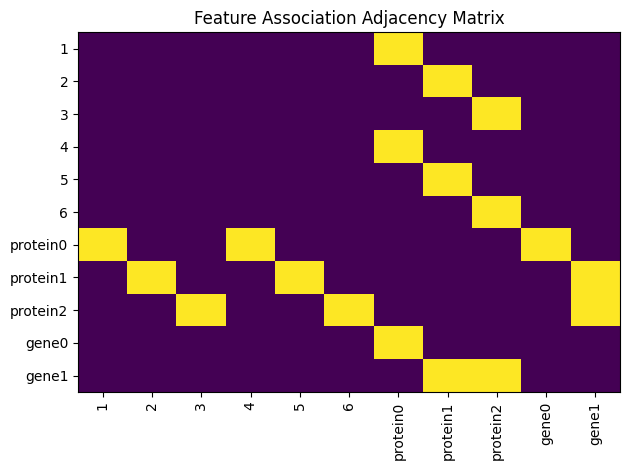

In [ ]:
from matplotlib import pyplot as plt

features = []
for mod in mdata.mod.values():
    features.extend(mod.var_names)

# heatmap
amdf = pd.DataFrame(mdata.varp['feature_mapping'].toarray())
plt.imshow(amdf, cmap='viridis', aspect='auto')
# xlabels and ylabels
plt.xticks(ticks=np.arange(len(features)), labels=features, rotation=90)
plt.yticks(ticks=np.arange(len(features)), labels=features)
plt.title('Feature Association Adjacency Matrix')
plt.tight_layout()